<a href="https://colab.research.google.com/github/eljaysmithdata/Data-Science-Bootcamp-2026/blob/main/Project_3_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 3 - SQL and Chinook

AI Disclosure: ChatGPT was used to support concept clarification, wording refinement and visualization formatting. Final code execution, interpretation, and submission decisions were completed independently.

## Problem Statement
How can Chinook use customer, invoice, and music data to understand where its strongest customer and sales signals are coming from?

In this project, I use SQL to move from raw database tables to focused business insights. Each small query builds on the last: first identifying the audience, then measuring sales performance, then connecting customer behavior to music trends.

The goal is to use SQL joins, filters, grouping, sorting, and aggregation to answer practical questions about customers, revenue, sales agents, and product patterns.

## Setup




In [1]:
import sqlite3 as db
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
%%capture install_output
%%bash
apt-get update
apt-get install -y sqlite3
pip install sqlite-web


In [3]:
!sqlite3 --version

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1


## Connect to Database

In [4]:
%%bash
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -l chinook.zip

Archive:  chinook.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   884736  2015-11-29 10:53   chinook.db
---------                     -------
   884736                     1 file


In [5]:
!unzip -u chinook.zip

Archive:  chinook.zip
  inflating: chinook.db              


## Inspect the Database

In [6]:
#list all folders and files
!ls -la


total 1180
drwxr-xr-x 1 root root   4096 May 25 05:10 .
drwxr-xr-x 1 root root   4096 May 25 05:07 ..
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db
-rw-r--r-- 1 root root 305596 May 25 05:10 chinook.zip
drwxr-xr-x 4 root root   4096 May 21 13:26 .config
drwxr-xr-x 1 root root   4096 May 21 13:27 sample_data


In [7]:
%%script sqlite3 --column --header chinook.db
.tables

albums          employees       invoices        playlists     
artists         genres          media_types     tracks        
customers       invoice_items   playlist_track


In [8]:
!sqlite3 chinook.db ".tables"

albums          employees       invoices        playlists     
artists         genres          media_types     tracks        
customers       invoice_items   playlist_track


In [9]:
%%script sqlite3 chinook.db
SELECT name FROM sqlite_master WHERE type='table';

albums
sqlite_sequence
artists
customers
employees
genres
invoices
invoice_items
media_types
playlists
playlist_track
tracks
sqlite_stat1


In [10]:
os.listdir()

['.config', 'chinook.zip', 'chinook.db', 'sample_data']

## Query using Python

## SQL Skills Covered

This project uses at least 13 required SQL options:

SELECT, WHERE, AND, OR, LIKE, BETWEEN, LIMIT, ORDER BY, DISTINCT, GROUP BY, JOIN, aggregate functions, aliases, subqueries/CTEs.



In [11]:
# Connect to a sqlite database and load a result set into a data frame
db_con = db.connect("chinook.db")

#### Query Flow #**1**

Here we pull the "raw signal."

In [12]:
# Preview all tables in the database

query = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

tables = pd.read_sql_query(query, db_con)
tables

,name
0,albums
1,artists
2,customers
3,employees
4,genres
5,invoice_items
6,invoices
7,media_types
8,playlist_track
9,playlists


In [13]:
# SELECT *
# Preview the raw Customer table

query = """

-- Step 1: SELECT *

SELECT *
FROM Customers
LIMIT 10
"""

pd.read_sql_query(query, db_con)

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,None,Ullevålsveien 14,Oslo,None,Norway,0171,+47 22 44 22 22,None,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,None,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4
5,6,Helena,Holý,None,Rilská 3174/6,Prague,None,Czech Republic,14300,+420 2 4177 0449,None,hholy@gmail.com,5
6,7,Astrid,Gruber,None,"Rotenturmstraße 4, 1010 Innere Stadt",Vienne,None,Austria,1010,+43 01 5134505,None,astrid.gruber@apple.at,5
7,8,Daan,Peeters,None,Grétrystraat 63,Brussels,None,Belgium,1000,+32 02 219 03 03,None,daan_peeters@apple.be,4
8,9,Kara,Nielsen,None,Sønder Boulevard 51,Copenhagen,None,Denmark,1720,+453 3331 9991,None,kara.nielsen@jubii.dk,4
9,10,Eduardo,Martins,Woodstock Discos,"Rua Dr. Falcão Filho, 155",São Paulo,SP,Brazil,01007-010,+55 (11) 3033-5446,+55 (11) 3033-4564,eduardo@woodstock.com.br,4


Then we narrow the focus on a signal

In [14]:
# SELECT with specific column names
# Focus only on useful customer signal

query = """

-- Step 2: SELECT specific columns

SELECT
    CustomerId,
    FirstName,
    LastName,
    Country,
    City,
    Email
FROM Customers
ORDER BY LastName
LIMIT 10
"""

pd.read_sql_query(query, db_con)

,CustomerId,FirstName,LastName,Country,City,Email
0,12,Roberto,Almeida,Brazil,Rio de Janeiro,roberto.almeida@riotur.gov.br
1,28,Julia,Barnett,USA,Salt Lake City,jubarnett@gmail.com
2,39,Camille,Bernard,France,Paris,camille.bernard@yahoo.fr
3,18,Michelle,Brooks,USA,New York,michelleb@aol.com
4,29,Robert,Brown,Canada,Toronto,robbrown@shaw.ca
5,21,Kathy,Chase,USA,Reno,kachase@hotmail.com
6,26,Richard,Cunningham,USA,Fort Worth,ricunningham@hotmail.com
7,41,Marc,Dubois,France,Lyon,marc.dubois@hotmail.com
8,34,João,Fernandes,Portugal,Lisbon,jfernandes@yahoo.pt
9,30,Edward,Francis,Canada,Ottawa,edfrancis@yachoo.ca


In [15]:
# WHERE
# Focus on customers outside the United States

query = """

SELECT
    CustomerId,
    FirstName,
    LastName,
    Country
FROM Customers
WHERE Country != 'USA'
ORDER BY Country, LastName
LIMIT 15;
"""

pd.read_sql_query(query, db_con)

,CustomerId,FirstName,LastName,Country
0,56,Diego,Gutiérrez,Argentina
1,55,Mark,Taylor,Australia
2,7,Astrid,Gruber,Austria
3,8,Daan,Peeters,Belgium
4,12,Roberto,Almeida,Brazil
5,1,Luís,Gonçalves,Brazil
6,10,Eduardo,Martins,Brazil
7,13,Fernanda,Ramos,Brazil
8,11,Alexandre,Rocha,Brazil
9,29,Robert,Brown,Canada


In [16]:
# COUNT + GROUP BY

query = """

-- Count how many customers are in each country.

SELECT DISTINCT
    Country,
    COUNT(*) AS CustomerCount
FROM Customers
GROUP BY Country
ORDER BY CustomerCount DESC;
"""

customers_by_country = pd.read_sql_query(query, db_con)
customers_by_country

,Country,CustomerCount
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4
5,United Kingdom,3
6,Portugal,2
7,India,2
8,Czech Republic,2
9,Sweden,1


##### Plot 1 - Customers per Country

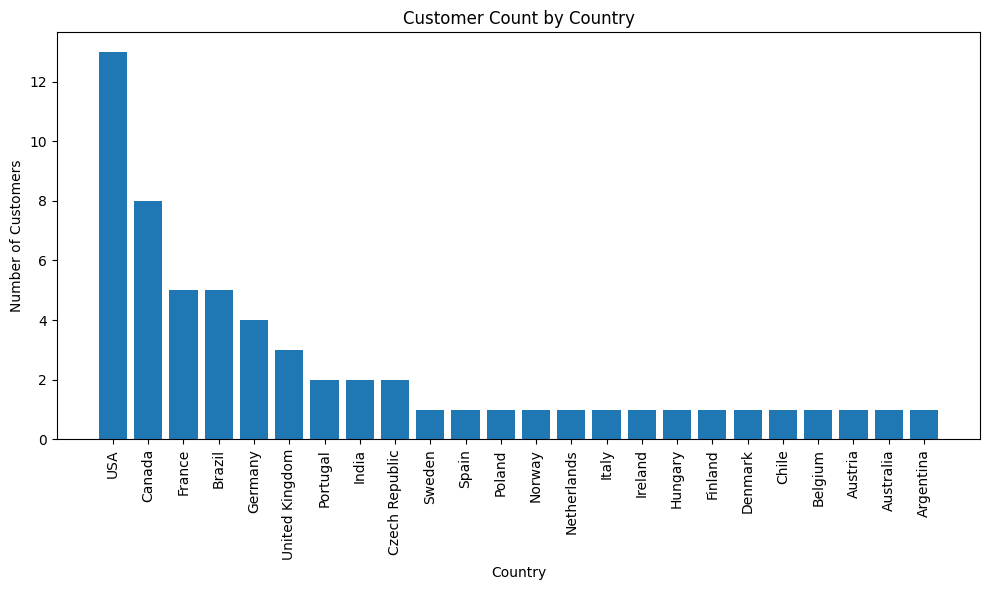

In [17]:
# Plot bar graph for number of customers per country
# Highlighting the "dominant frequencies" (Top 3 countries)

plt.figure(figsize=(10, 6))
plt.bar(customers_by_country["Country"], customers_by_country["CustomerCount"])
plt.title("Customer Count by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

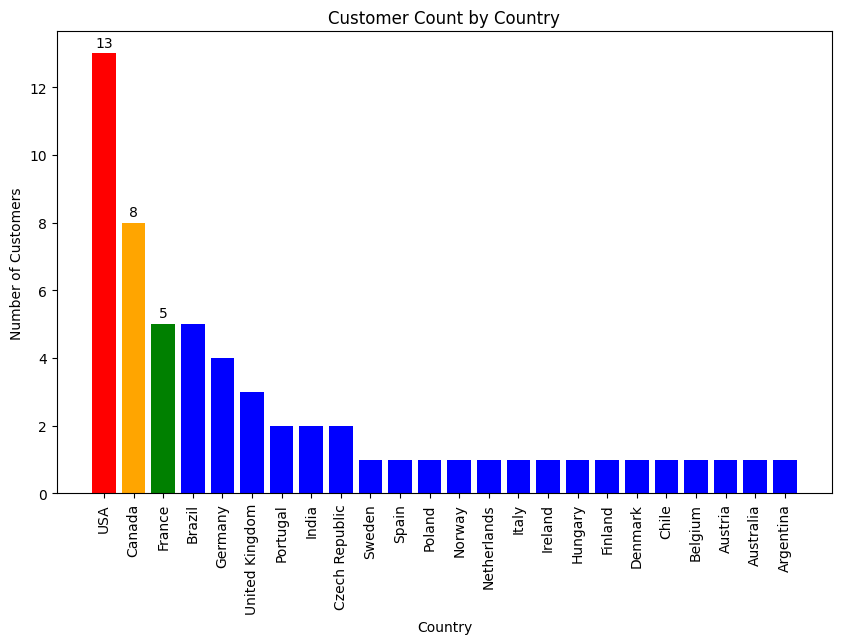

In [18]:
# Simple color setup
colors = ["blue"] * len(customers_by_country)

# Highlight top 3
colors[0] = "red"
colors[1] = "orange"
colors[2] = "green"

# Create plot
plt.figure(figsize=(10,6))

plt.bar(
    customers_by_country["Country"],
    customers_by_country["CustomerCount"],
    color=colors
)

# Labels
plt.title("Customer Count by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

# Rotate x labels
plt.xticks(rotation=90)

# Add simple value labels to top 3 - code provided by ChatGPT
for i in range(3):
    plt.text(
        i,
        customers_by_country.iloc[i]["CustomerCount"] + 0.2,
        customers_by_country.iloc[i]["CustomerCount"],
        ha='center'
    )

plt.show()

In [19]:
# AND
# Find customers from Brazil in specific cities

query = """

-- Step 5: ORDER BY
-- Sort customers by country so the pattern is easier to read.

SELECT
    CustomerId,
    FirstName,
    LastName,
    Country,
    City
FROM Customers
WHERE Country = 'Brazil'
AND City = 'São Paulo';

"""

brazil_sao_paulo = pd.read_sql_query(query, db_con)
brazil_sao_paulo

,CustomerId,FirstName,LastName,Country,City
0,10,Eduardo,Martins,Brazil,São Paulo
1,11,Alexandre,Rocha,Brazil,São Paulo


In [20]:
# OR
# Find customers from Brazil or Canada

query = """
SELECT
    CustomerId,
    FirstName,
    LastName,
    Country
FROM Customers
WHERE Country = 'Brazil'
OR Country = 'Canada'
ORDER BY Country, LastName;
"""

brazil_or_canada = pd.read_sql_query(query, db_con)
brazil_or_canada

,CustomerId,FirstName,LastName,Country
0,12,Roberto,Almeida,Brazil
1,1,Luís,Gonçalves,Brazil
2,10,Eduardo,Martins,Brazil
3,13,Fernanda,Ramos,Brazil
4,11,Alexandre,Rocha,Brazil
5,29,Robert,Brown,Canada
6,30,Edward,Francis,Canada
7,32,Aaron,Mitchell,Canada
8,15,Jennifer,Peterson,Canada
9,14,Mark,Philips,Canada


In [21]:
# LIKE with wildcard
# Find customers with email addresses containing "gmail"

query = """
SELECT
    CustomerId,
    FirstName,
    LastName,
    Email
FROM Customers
WHERE Email LIKE '%gmail%';
"""

gmail_customers = pd.read_sql_query(query, db_con)
gmail_customers

,CustomerId,FirstName,LastName,Email
0,3,François,Tremblay,ftremblay@gmail.com
1,6,Helena,Holý,hholy@gmail.com
2,22,Heather,Leacock,hleacock@gmail.com
3,24,Frank,Ralston,fralston@gmail.com
4,28,Julia,Barnett,jubarnett@gmail.com
5,31,Martha,Silk,marthasilk@gmail.com
6,40,Dominique,Lefebvre,dominiquelefebvre@gmail.com
7,53,Phil,Hughes,phil.hughes@gmail.com


### Query Flow #2

Measuring Sales Signal

In [22]:
# BETWEEN
# Find invoices within a specific date range

query = """
SELECT
    InvoiceId,
    CustomerId,
    InvoiceDate,
    BillingCountry,
    Total
FROM Invoices
WHERE InvoiceDate BETWEEN '2009-01-01' AND '2009-12-31'
ORDER BY InvoiceDate;
"""

invoices_2009 = pd.read_sql_query(query, db_con)
invoices_2009

,InvoiceId,CustomerId,InvoiceDate,BillingCountry,Total
0,1,2,2009-01-01 00:00:00,Germany,1.98
1,2,4,2009-01-02 00:00:00,Norway,3.96
2,3,8,2009-01-03 00:00:00,Belgium,5.94
3,4,14,2009-01-06 00:00:00,Canada,8.91
4,5,23,2009-01-11 00:00:00,USA,13.86
...,...,...,...,...,...
78,79,9,2009-12-09 00:00:00,Denmark,3.96
79,80,13,2009-12-10 00:00:00,Brazil,5.94
80,81,19,2009-12-13 00:00:00,USA,8.91
81,82,28,2009-12-18 00:00:00,USA,13.86


In [23]:
# WHERE, GROUP BY and ORDER BY

query = """
SELECT
    BillingCountry,
    SUM(Total) AS TotalSales
FROM Invoices
WHERE InvoiceDate BETWEEN '2009-01-01' AND '2009-12-31'
GROUP BY BillingCountry
ORDER BY TotalSales DESC;
"""

sales_2009_by_country = pd.read_sql_query(query, db_con)
sales_2009_by_country

,BillingCountry,TotalSales
0,USA,103.95
1,Canada,57.42
2,Germany,53.46
3,Brazil,37.62
4,France,35.64
5,United Kingdom,25.74
6,Poland,15.84
7,Chile,15.84
8,Portugal,11.88
9,Australia,11.88


#### Plot 2 — 2009 Invoice Totals

Filtered Signal: 2009 Invoice Totals by Country

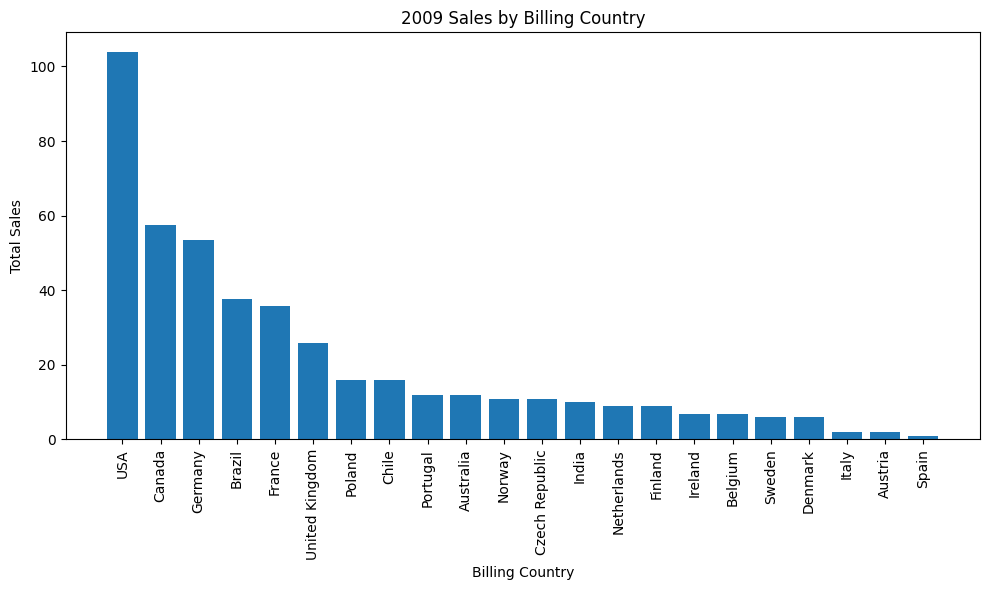

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(sales_2009_by_country["BillingCountry"], sales_2009_by_country["TotalSales"])
plt.title("2009 Sales by Billing Country")
plt.xlabel("Billing Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [25]:
# JOIN
# Connect customers and invoices

query = """
SELECT
    c.CustomerId,
    c.FirstName || ' ' || c.LastName AS CustomerName,
    c.Country,
    i.InvoiceId,
    i.InvoiceDate,
    i.Total
FROM Customers AS c
JOIN Invoices AS i
    ON c.CustomerId = i.CustomerId
ORDER BY i.InvoiceDate
LIMIT 15;
"""

customer_invoices = pd.read_sql_query(query, db_con)
customer_invoices

,CustomerId,CustomerName,Country,InvoiceId,InvoiceDate,Total
0,2,Leonie Köhler,Germany,1,2009-01-01 00:00:00,1.98
1,4,Bjørn Hansen,Norway,2,2009-01-02 00:00:00,3.96
2,8,Daan Peeters,Belgium,3,2009-01-03 00:00:00,5.94
3,14,Mark Philips,Canada,4,2009-01-06 00:00:00,8.91
4,23,John Gordon,USA,5,2009-01-11 00:00:00,13.86
5,37,Fynn Zimmermann,Germany,6,2009-01-19 00:00:00,0.99
6,38,Niklas Schröder,Germany,7,2009-02-01 00:00:00,1.98
7,40,Dominique Lefebvre,France,8,2009-02-01 00:00:00,1.98
8,42,Wyatt Girard,France,9,2009-02-02 00:00:00,3.96
9,46,Hugh O'Reilly,Ireland,10,2009-02-03 00:00:00,5.94


In [26]:
# JOIN with employees/sales agents
# Connect customer behavior to sales support

query = """
SELECT
    e.FirstName || ' ' || e.LastName AS SalesAgent,
    c.FirstName || ' ' || c.LastName AS CustomerName,
    c.Country,
    i.InvoiceId,
    i.Total
FROM Employees AS e
JOIN Customers AS c
    ON e.EmployeeId = c.SupportRepId
JOIN Invoices AS i
    ON c.CustomerId = i.CustomerId
ORDER BY SalesAgent, i.Total DESC
LIMIT 20;
"""

sales_agent_invoices = pd.read_sql_query(query, db_con)
sales_agent_invoices

,SalesAgent,CustomerName,Country,InvoiceId,Total
0,Jane Peacock,Ladislav Kovács,Hungary,96,21.86
1,Jane Peacock,Hugh O'Reilly,Ireland,194,21.86
2,Jane Peacock,Isabelle Mercier,France,313,16.86
3,Jane Peacock,Frank Ralston,USA,103,15.86
4,Jane Peacock,Fynn Zimmermann,Germany,193,14.91
5,Jane Peacock,Luís Gonçalves,Brazil,327,13.86
6,Jane Peacock,François Tremblay,Canada,110,13.86
7,Jane Peacock,Roberto Almeida,Brazil,166,13.86
8,Jane Peacock,Jennifer Peterson,Canada,47,13.86
9,Jane Peacock,Michelle Brooks,USA,341,13.86


In [27]:
# JOIN

query = """
SELECT
    e.FirstName || ' ' || e.LastName AS SalesAgent,
    SUM(i.Total) AS TotalSales
FROM Employees AS e
JOIN Customers AS c
    ON e.EmployeeId = c.SupportRepId
JOIN Invoices AS i
    ON c.CustomerId = i.CustomerId
GROUP BY SalesAgent
ORDER BY TotalSales DESC;
"""

sales_by_agent = pd.read_sql_query(query, db_con)
sales_by_agent

,SalesAgent,TotalSales
0,Jane Peacock,833.04
1,Margaret Park,775.40
2,Steve Johnson,720.16


#### Plot 3 - Sales by Sales Agent

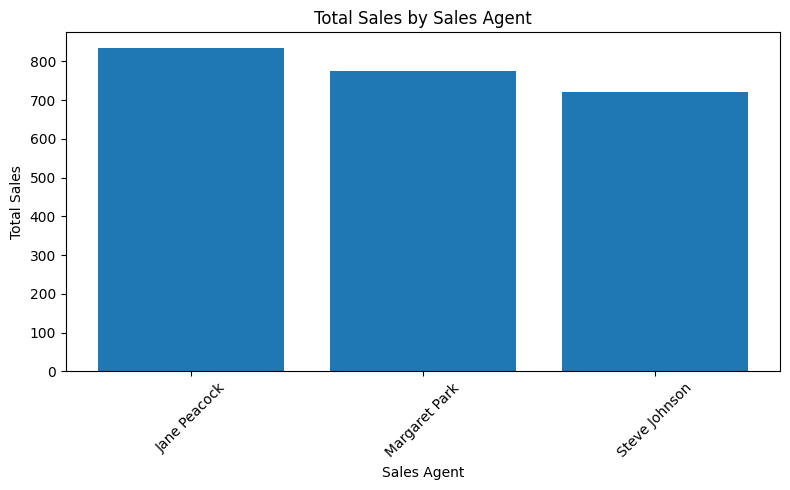

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(sales_by_agent["SalesAgent"], sales_by_agent["TotalSales"])
plt.title("Total Sales by Sales Agent")
plt.xlabel("Sales Agent")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# DISTINCT
# Find unique billing countries

query = """
SELECT DISTINCT
    BillingCountry
FROM Invoices
ORDER BY BillingCountry;
"""

unique_billing_countries = pd.read_sql_query(query, db_con)
unique_billing_countries

,BillingCountry
0,Argentina
1,Australia
2,Austria
3,Belgium
4,Brazil
5,Canada
6,Chile
7,Czech Republic
8,Denmark
9,Finland


In [30]:
# GROUP BY, COUNT, SUM, ORDER BY
# Summarize invoices and sales by country

query = """
SELECT
    BillingCountry,
    COUNT(InvoiceId) AS InvoiceCount,
    SUM(Total) AS TotalSales,
    AVG(Total) AS AverageInvoice
FROM Invoices
GROUP BY BillingCountry
ORDER BY TotalSales DESC;
"""

country_sales_summary = pd.read_sql_query(query, db_con)
country_sales_summary

,BillingCountry,InvoiceCount,TotalSales,AverageInvoice
0,USA,91,523.06,5.747912
1,Canada,56,303.96,5.427857
2,France,35,195.10,5.574286
3,Brazil,35,190.10,5.431429
4,Germany,28,156.48,5.588571
5,United Kingdom,21,112.86,5.374286
6,Czech Republic,14,90.24,6.445714
7,Portugal,14,77.24,5.517143
8,India,13,75.26,5.789231
9,Chile,7,46.62,6.660000


#### Plot 4 - Total Sales per Country

### Query Flow #3

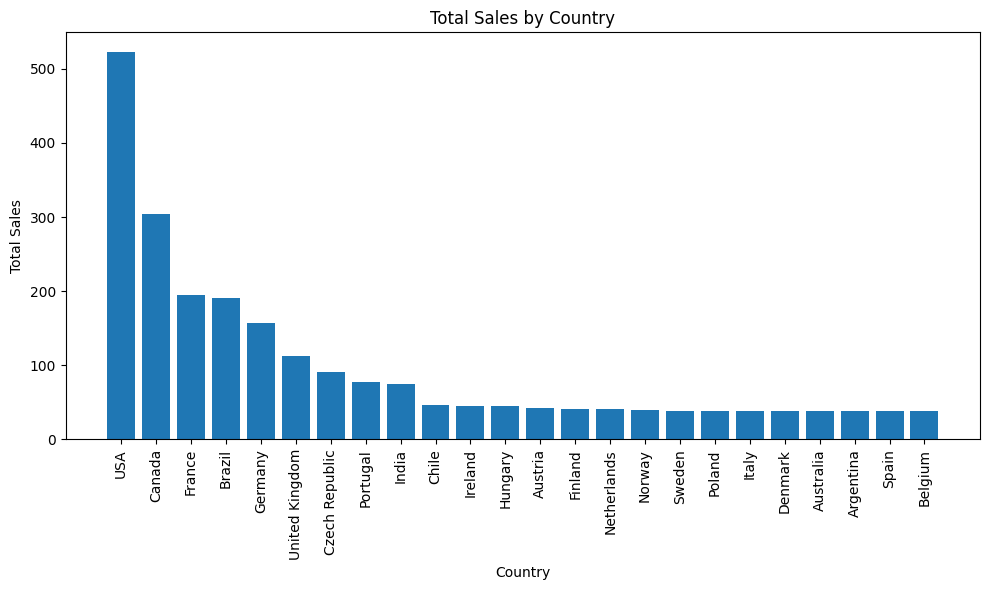

In [31]:
# Plot bar graph of Total Sales by Country

plt.figure(figsize=(10, 6))
plt.bar(country_sales_summary["BillingCountry"], country_sales_summary["TotalSales"])
plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [32]:
# Final query:
# Which genres generate the most revenue?

query = """
SELECT
    g.Name AS Genre,
    COUNT(ii.InvoiceLineId) AS TracksSold,
    SUM(ii.UnitPrice * ii.Quantity) AS TotalRevenue
FROM genres AS g
JOIN tracks AS t
    ON g.GenreId = t.GenreId
JOIN invoice_items AS ii
    ON t.TrackId = ii.TrackId
GROUP BY g.Name
ORDER BY TotalRevenue DESC
LIMIT 10;
"""

genre_revenue = pd.read_sql_query(query, db_con)

genre_revenue

,Genre,TracksSold,TotalRevenue
0,Rock,835,826.65
1,Latin,386,382.14
2,Metal,264,261.36
3,Alternative & Punk,244,241.56
4,TV Shows,47,93.53
5,Jazz,80,79.20
6,Blues,61,60.39
7,Drama,29,57.71
8,R&B/Soul,41,40.59
9,Classical,41,40.59


In [33]:
# GROUP BY, ORDER BY and LIMIT

query = """


SELECT
    Country,
    COUNT(CustomerId) AS CustomerCount
FROM Customers
GROUP BY Country
ORDER BY CustomerCount DESC
LIMIT 10;

"""

pd.read_sql_query(query, db_con)

,Country,CustomerCount
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4
5,United Kingdom,3
6,Portugal,2
7,India,2
8,Czech Republic,2
9,Sweden,1


#### Plot 5 - Top 10 Genres by Revenue

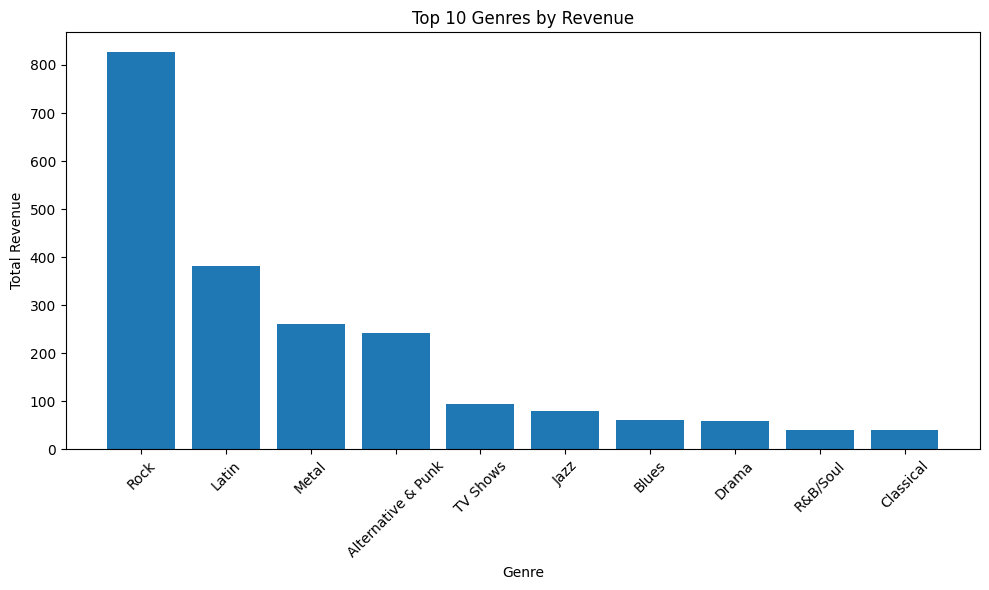

In [34]:
# Plot bar graph of Top 10 Genres by Revenue

plt.figure(figsize=(10, 6))
plt.bar(genre_revenue["Genre"], genre_revenue["TotalRevenue"])
plt.title("Top 10 Genres by Revenue")
plt.xlabel("Genre")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Final Takeaways
This project showed how SQL can turn a relational database into a clean, structured signal.

In Project 1, I focused on hearing signal inside noisy, imbalanced data.
In Project 2, linear regression became the mixing board where assumptions helped ensure the signal was trustworthy.
In this project, SQL became the studio itself.

I started with raw tracks: disconnected tables full of customers, invoices, employees, artists, and music data.  Then, step by step, I filtered noise, isolated patterns, connected related signals through joins, and shaped the results into something meaningful.

Each query acted like another adjustment in the mix:
- SELECT pulled in the raw sound
- WHERE filtered unwanted noise
- JOIN connected layers together
- GROUP BY organized the rhythm of the data
- ORDER BY brought the strongest signals forward

By the end, the database stopped feeling like separate tables and started behaving like a complete mix.

The biggest takeaway is that SQL is not just a tool for retrieving data. It is a way to shape information intentionally before the analysis even reaches Python or visualization.

I wasn’t just querying data.  I was mixing it into meaning.

In [35]:
print("Project 3 Summary:")
print("I started with raw customer and invoice data.")
print("Then I selected useful columns, filtered patterns, joined tables, summarized trends, and visualized the strongest signals.")
print("SQL became the process of shaping raw information into a final mix.")

Project 3 Summary:
I started with raw customer and invoice data.
Then I selected useful columns, filtered patterns, joined tables, summarized trends, and visualized the strongest signals.
SQL became the process of shaping raw information into a final mix.
